# 🔗 ImageBind — CSC14005 Final Project
**Topic 17 | Nhóm 2 người | Focused type**

| Tuần | Nội dung |
|------|----------|
| Tuần 1 | Setup môi trường · Clone repo · Chạy demo · Chuẩn bị data |
| Tuần 2 | Training loop · Checkpoint · Evaluate · Viết metric |
| Tuần 3 | Benchmark hyperparams · Full evaluate · Vẽ biểu đồ |

> **Chạy trên Kaggle**: Accelerator → GPU T4 x2 · Internet → ON

---
# 📗 TUẦN 1 — Setup & Chuẩn bị

## 1.1 Cài đặt môi trường

In [1]:
# Clone repo ImageBind
import os

if not os.path.exists('ImageBind'):
    !git clone https://github.com/facebookresearch/ImageBind.git
    print('Cloned!')
else:
    print('Repo da ton tai, bo qua.')

%cd ImageBind

# Cai dependencies
!pip install -q .
!pip install -q timm ftfy regex einops fvcore tqdm matplotlib seaborn pandas
print('\n=== Cai dat xong ===')

Cloning into 'ImageBind'...
remote: Enumerating objects: 187, done.
remote: Counting objects: 100% (120/120), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 187 (delta 84), reused 48 (delta 48), pack-reused 67 (from 2)
Receiving objects: 100% (187/187), 2.65 MiB | 12.29 MiB/s, done.
Resolving deltas: 100% (92/92), done.
Cloned!
/kaggle/working/ImageBind
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 51.8 MB/s eta 0:00:00:00:0100:01

=== Cai dat xong ===


In [2]:
import os
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

import torch

print('=== Kiem tra moi truong ===')
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'\nSu dung device  : {DEVICE}')

=== Kiem tra moi truong ===
PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
VRAM            : 15.6 GB

Su dung device  : cuda


## 1.2 Tải pretrained weights

In [3]:
import os

os.makedirs('.checkpoints', exist_ok=True)
WEIGHT_PATH = '.checkpoints/imagebind_huge.pth'

if not os.path.exists(WEIGHT_PATH):
    print('Dang tai pretrained weights (~2GB)...')
    !wget -q --show-progress -O {WEIGHT_PATH} \
        https://dl.fbaipublicfiles.com/imagebind/imagebind_huge.pth
    print('Tai xong!')
else:
    size_mb = os.path.getsize(WEIGHT_PATH) / 1e6
    print(f'Weights da co san: {size_mb:.0f} MB')

Dang tai pretrained weights (~2GB)...
.checkpoints/imageb 100%[===================>]   4.47G  58.7MB/s    in 83s     
Tai xong!


## 1.3 Load model & Smoke test (demo pipeline)

In [4]:
from imagebind import data as ibdata
from imagebind.models import imagebind_model
from imagebind.models.imagebind_model import ModalityType

print('Dang load model...')
model = imagebind_model.imagebind_huge(pretrained=True)
model.eval()
model.to(DEVICE)
print('Load model thanh cong!')

# Kiem tra so luong params
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTong params      : {total_params / 1e6:.1f}M')
print(f'Trainable params : {trainable_params / 1e6:.1f}M')

Dang load model...
Load model thanh cong!

Tong params      : 1200.8M
Trainable params : 1200.8M


In [5]:
# Smoke test: thu text embedding
import torch

texts = [
    'A dog is barking',
    'Fire crackling sound',
    'Ocean waves crashing',
    'Rain falling on roof',
]

inputs = {
    ModalityType.TEXT: ibdata.load_and_transform_text(texts, DEVICE)
}

with torch.no_grad():
    embeddings = model(inputs)

emb = embeddings[ModalityType.TEXT]
print(f'Text embedding shape: {emb.shape}')  # Expected: [4, 1024]
print(f'Embedding norm      : {emb.norm(dim=-1)}')  # Should be ~1.0 (normalized)

# Cosine similarity giua cac text
sim = emb @ emb.T
print(f'\nCosine similarity matrix:')
import pandas as pd
labels = ['dog', 'fire', 'ocean', 'rain']
print(pd.DataFrame(sim.cpu().numpy().round(3), index=labels, columns=labels))
print('\n=== Smoke test PASS ===')

# [FIX OOM] Xoa model smoke-test de giai phong VRAM
del embeddings
import gc; gc.collect()
torch.cuda.empty_cache()
print(f'VRAM sau smoke-test: {torch.cuda.memory_allocated()/1e9:.2f} GB allocated')

Text embedding shape: torch.Size([4, 1024])
Embedding norm      : tensor([100.0000, 100.0000, 100.0000, 100.0000], device='cuda:0')

Cosine similarity matrix:
                dog         fire        ocean          rain
dog    10000.000000  4784.596191  3606.572998   3474.736084
fire    4784.596191  9999.999023  3955.220947   3414.861084
ocean   3606.572998  3955.220947  9999.998047   4391.550781
rain    3474.736084  3414.861084  4391.550781  10000.000977

=== Smoke test PASS ===
VRAM sau smoke-test: 4.81 GB allocated


## 1.4 Chuẩn bị dataset — ESC-50 (Audio Classification)

In [8]:
# Su dung ESC-50 tu Kaggle dataset
import os, glob

ESC50_AUDIO_DIR = '/kaggle/input/datasets/hongngctng/dataesc50/ESC-50-master/audio'
ESC50_META_PATH = '/kaggle/input/datasets/hongngctng/dataesc50/ESC-50-master/meta/esc50.csv'

if not os.path.exists(ESC50_AUDIO_DIR):
    print('Kaggle dataset not found, cloning from GitHub...')
    if not os.path.exists('ESC-50'):
        os.system('git clone https://github.com/karolpiczak/ESC-50.git')
    ESC50_AUDIO_DIR = 'ESC-50/audio'
    ESC50_META_PATH = 'ESC-50/meta/esc50.csv'

audio_files = glob.glob(f'{ESC50_AUDIO_DIR}/*.wav')
print(f'So file audio: {len(audio_files)}')
print(f'Vi du         : {audio_files[0] if audio_files else "Khong tim thay"}')


So file audio: 2000
Vi du         : /kaggle/input/datasets/hongngctng/dataesc50/ESC-50-master/audio/5-257349-A-15.wav


=== ESC-50 Dataset Info ===
            filename  fold  target        category  esc10  src_file take
0   1-100032-A-0.wav     1       0             dog   True    100032    A
1  1-100038-A-14.wav     1      14  chirping_birds  False    100038    A
2  1-100210-A-36.wav     1      36  vacuum_cleaner  False    100210    A
3  1-100210-B-36.wav     1      36  vacuum_cleaner  False    100210    B
4  1-101296-A-19.wav     1      19    thunderstorm  False    101296    A

Tong so mau  : 2000
So class     : 50
So fold      : 5

Cac class (10 dau):
category
dog                40
chirping_birds     40
vacuum_cleaner     40
thunderstorm       40
door_wood_knock    40
can_opening        40
crow               40
clapping           40
fireworks          40
chainsaw           40
Name: count, dtype: int64


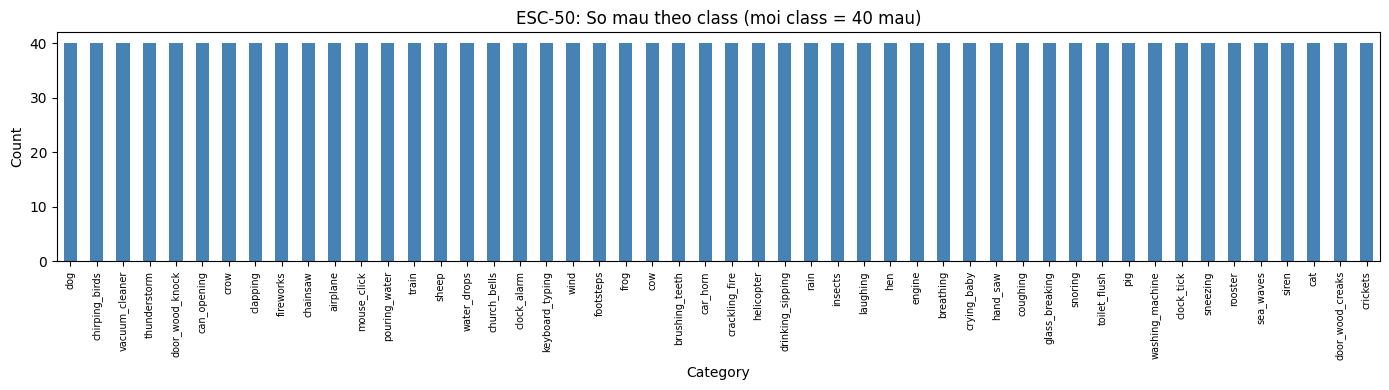

Luu bieu do: esc50_distribution.png


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Doc metadata
meta = pd.read_csv('/kaggle/input/datasets/hongngctng/dataesc50/ESC-50-master/meta/esc50.csv')
print('=== ESC-50 Dataset Info ===')
print(meta.head(5))
print(f'\nTong so mau  : {len(meta)}')
print(f'So class     : {meta["category"].nunique()}')
print(f'So fold      : {meta["fold"].nunique()}')
print(f'\nCac class (10 dau):')
print(meta['category'].value_counts().head(10))

# Plot phan phoi class
fig, ax = plt.subplots(figsize=(14, 4))
meta['category'].value_counts().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('ESC-50: So mau theo class (moi class = 40 mau)')
ax.set_xlabel('Category')
ax.set_ylabel('Count')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig('esc50_distribution.png', dpi=100)
plt.show()
print('Luu bieu do: esc50_distribution.png')

In [10]:
import os
import torch
import torchaudio
import numpy as np
from torch.utils.data import Dataset, DataLoader
import pandas as pd

class ESC50Dataset(Dataset):
    """
    ESC-50 dataset wrapper cho ImageBind.
    Tra ve (mel_spectrogram, label) cho moi audio clip.
    """
    def __init__(self, meta_path, audio_dir, folds, target_sr=16000, duration=2.0):
        self.meta = pd.read_csv(meta_path)
        self.meta = self.meta[self.meta['fold'].isin(folds)].reset_index(drop=True)
        self.audio_dir = audio_dir
        self.target_sr = target_sr
        self.num_samples = int(target_sr * duration)
        
        # Map category -> int label
        categories = sorted(self.meta['category'].unique())
        self.class2idx = {c: i for i, c in enumerate(categories)}
        self.idx2class = {i: c for c, i in self.class2idx.items()}
        self.class_names = categories

    def __len__(self):
        return len(self.meta)

    def _load_audio(self, filepath):
        waveform, sr = torchaudio.load(filepath)
        # Resample neu can
        if sr != self.target_sr:
            resampler = torchaudio.transforms.Resample(sr, self.target_sr)
            waveform = resampler(waveform)
        # Convert to mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        # Pad hoac cat cho du duration
        if waveform.shape[1] < self.num_samples:
            waveform = torch.nn.functional.pad(waveform, (0, self.num_samples - waveform.shape[1]))
        else:
            waveform = waveform[:, :self.num_samples]
        return waveform

    def _waveform_to_melspec(self, waveform):
        """Chuyen waveform -> mel-spectrogram (128 bins) theo paper ImageBind"""
        mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=self.target_sr,
            n_fft=400,
            win_length=400,      # 25ms window
            hop_length=160,      # 10ms hop
            n_mels=128,
        )
        mel = mel_transform(waveform)             # (1, 128, T)
        mel = torchaudio.transforms.AmplitudeToDB()(mel)
        mel = mel.squeeze(0)                      # (128, T)
        # Normalize
        mel = (mel - mel.mean()) / (mel.std() + 1e-6)
        return mel

    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        filepath = os.path.join(self.audio_dir, row['filename'])
        waveform = self._load_audio(filepath)
        mel = self._waveform_to_melspec(waveform)
        label = self.class2idx[row['category']]
        return mel, label


# Khoi tao dataset
# Fold 1-4: train | Fold 5: test (theo chuan ESC-50)
train_dataset = ESC50Dataset(
    meta_path=ESC50_META_PATH,
    audio_dir=ESC50_AUDIO_DIR,
    folds=[1, 2, 3, 4]
)
test_dataset = ESC50Dataset(
    meta_path=ESC50_META_PATH,
    audio_dir=ESC50_AUDIO_DIR,
    folds=[5]
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train samples : {len(train_dataset)}')
print(f'Test  samples : {len(test_dataset)}')
print(f'So classes    : {len(train_dataset.class_names)}')
print(f'Class names   : {train_dataset.class_names[:5]}...')

# Kiem tra 1 batch
mel, label = next(iter(train_loader))
print(f'\nBatch mel shape : {mel.shape}')
print(f'Batch label     : {label[:5]}')
print('=== Dataset OK ===')

Train samples : 1600
Test  samples : 400
So classes    : 50
Class names   : ['airplane', 'breathing', 'brushing_teeth', 'can_opening', 'car_horn']...


/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(



Batch mel shape : torch.Size([16, 128, 201])
Batch label     : tensor([12, 13, 38, 42, 11])
=== Dataset OK ===


---
# 📘 TUẦN 2 — Training Loop & Evaluate

## 2.1 Cấu hình training

In [11]:
# ============================================================
# CAU HINH TRAINING — chinh sua o day
# ============================================================
CONFIG = {
    # Training
    'num_epochs'    : 2,          # >= 1 de dat muc Mini
    'batch_size'    : 16,         # Giam xuong 16 de tranh OOM
    'lr'            : 1.6e-3,
    'weight_decay'  : 0.2,
    'grad_clip'     : 1.0,
    'temperature'   : 0.05,       # tau cho InfoNCE loss

    # Checkpoint
    'ckpt_dir'      : 'checkpoints',
    'log_interval'  : 5,          # log moi N steps

    # Freeze
    'freeze_vision' : True,       # Freeze vision encoder (theo paper)
    'freeze_text'   : True,       # Freeze text encoder
}

import os
os.makedirs(CONFIG['ckpt_dir'], exist_ok=True)
os.makedirs('results', exist_ok=True)

print('Config:')
for k, v in CONFIG.items():
    print(f'  {k:20s}: {v}')

Config:
  num_epochs          : 2
  batch_size          : 16
  lr                  : 0.0016
  weight_decay        : 0.2
  grad_clip           : 1.0
  temperature         : 0.05
  ckpt_dir            : checkpoints
  log_interval        : 5
  freeze_vision       : True
  freeze_text         : True


## 2.2 Setup model để train

In [12]:
import gc, torch
# [FIX OOM] Xoa model smoke-test truoc khi load train_model
if 'model' in dir(): del model
gc.collect(); torch.cuda.empty_cache()
print(f'VRAM truoc khi load train_model: {torch.cuda.memory_allocated()/1e9:.2f} GB')

from imagebind.models import imagebind_model

# Load model moi hoan toan de train
train_model = imagebind_model.imagebind_huge(pretrained=True)
train_model.to(DEVICE)

# Freeze encoder theo config
frozen, trainable = 0, 0
for name, param in train_model.named_parameters():
    should_freeze = (
        (CONFIG['freeze_vision'] and 'modality_trunks.vision' in name) or
        (CONFIG['freeze_text']   and 'modality_trunks.text'   in name) or
        ('modality_postprocessors.vision' in name) or
        ('modality_postprocessors.text'   in name)
    )
    param.requires_grad = not should_freeze
    if should_freeze:
        frozen    += param.numel()
    else:
        trainable += param.numel()

print(f'Frozen params    : {frozen    / 1e6:.1f}M')
print(f'Trainable params : {trainable / 1e6:.1f}M')

# Optimizer
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, train_model.parameters()),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay'],
    betas=(0.9, 0.95),
)

# LR scheduler (cosine)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CONFIG['num_epochs'],
    eta_min=1e-5,
)

print('Optimizer va Scheduler da san sang.')

VRAM truoc khi load train_model: 0.01 GB
Frozen params    : 932.0M
Trainable params : 268.8M
Optimizer va Scheduler da san sang.


## 2.3 InfoNCE Loss

In [13]:
import torch
import torch.nn.functional as F

def infonce_loss(emb_i, emb_m, temperature):
    """
    Symmetric InfoNCE loss (Equation 1 trong paper ImageBind).

    Args:
        emb_i : Tensor (B, D) - image embedding
        emb_m : Tensor (B, D) - modality embedding  
        temperature: float - tau

    Returns:
        loss : scalar
    """
    # L2 normalize
    q = F.normalize(emb_i, dim=-1)   # (B, D)
    k = F.normalize(emb_m, dim=-1)   # (B, D)

    # Logits: (B, B) - moi cap (i, j)
    logits = q @ k.T / temperature

    # Labels: diagonal la positive
    labels = torch.arange(len(q), device=q.device)

    # L(I->M) + L(M->I)
    loss_im = F.cross_entropy(logits,   labels)
    loss_mi = F.cross_entropy(logits.T, labels)

    return (loss_im + loss_mi) / 2


# Test loss voi random tensors
q_test = torch.randn(8, 1024)
k_test = torch.randn(8, 1024)
loss_test = infonce_loss(q_test, k_test, temperature=0.05)
print(f'Test loss (random input, ky vong ~log(8)={torch.log(torch.tensor(8.)):.3f}): {loss_test:.3f}')
print('InfoNCE loss OK!')

Test loss (random input, ky vong ~log(8)=2.079): 2.532
InfoNCE loss OK!


## 2.4 Training Loop chính

In [14]:
import json
import time
from tqdm import tqdm
import torch

def train_one_epoch(model, loader, optimizer, epoch, config, class_names):
    """
    Train 1 epoch tren ESC-50.
    Strategy: dung text embedding cua class name lam 'image proxy'
    (vi ta khong co anh tuong ung voi audio trong ESC-50)
    => align (text_class, audio) thay vi (image, audio)
    """
    model.train()
    total_loss = 0
    start = time.time()

    # [FIX OOM] Pre-compute text embs 1 lan / epoch thay vi moi batch
    with torch.no_grad():
        _all_text_in = {ModalityType.TEXT: ibdata.load_and_transform_text(class_names, DEVICE)}
        _all_text_embs = model(_all_text_in)[ModalityType.TEXT]  # (C, 1024)

    pbar = tqdm(loader, desc=f'Epoch {epoch}', leave=True)
    for step, (mel_batch, label_batch) in enumerate(pbar):
        mel_batch   = mel_batch.to(DEVICE)    # (B, 128, T)
        label_batch = label_batch.to(DEVICE)

        # Lay text emb tu cache theo label (khong forward text encoder lai)
        text_emb = _all_text_embs[label_batch]  # (B, 1024)

        # Audio embedding — phan nay duoc update
        # Reshape mel -> phu hop voi ImageBind audio input
        # ImageBind can: (B, 1, 128, T)
        mel_input = mel_batch.unsqueeze(1)    # (B, 1, 128, T)

        audio_inputs = {
            ModalityType.AUDIO: mel_input
        }
        audio_emb = model(audio_inputs)[ModalityType.AUDIO]   # (B, 1024)

        # Tinh loss
        loss = infonce_loss(text_emb, audio_emb, config['temperature'])

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), config['grad_clip']
        )
        optimizer.step()

        total_loss += loss.item()

        if step % config['log_interval'] == 0:
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(loader)
    elapsed  = time.time() - start
    print(f'  Epoch {epoch} | Avg Loss: {avg_loss:.4f} | Time: {elapsed:.0f}s')
    return avg_loss


# ============================================================
# CHAY TRAINING
# ============================================================
training_log = []

print(f'=== Bat dau train {CONFIG["num_epochs"]} epoch(s) ===')

for epoch in range(1, CONFIG['num_epochs'] + 1):
    avg_loss = train_one_epoch(
        model=train_model,
        loader=train_loader,
        optimizer=optimizer,
        epoch=epoch,
        config=CONFIG,
        class_names=train_dataset.class_names,
    )
    scheduler.step()

    # Log
    training_log.append({
        'epoch'   : epoch,
        'loss'    : round(avg_loss, 6),
        'lr'      : scheduler.get_last_lr()[0],
        'temperature': CONFIG['temperature'],
    })

    # Luu checkpoint
    ckpt_path = f'{CONFIG["ckpt_dir"]}/epoch_{epoch:02d}_loss{avg_loss:.4f}.pth'
    torch.save({
        'epoch'          : epoch,
        'model_state'    : train_model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'loss'           : avg_loss,
        'config'         : CONFIG,
    }, ckpt_path)
    print(f'  Checkpoint saved: {ckpt_path}')

# Luu log
with open('results/training_log.json', 'w') as f:
    json.dump(training_log, f, indent=2)

print('\n=== Training hoan tat ===')
print(f'Log da luu: results/training_log.json')

=== Bat dau train 2 epoch(s) ===


Epoch 1:   0%|          | 0/100 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
Epoch 1: 100%|██████████| 100/100 [01:01<00:00,  1.62it/s, loss=2.8481]


  Epoch 1 | Avg Loss: 2.8643 | Time: 63s
  Checkpoint saved: checkpoints/epoch_01_loss2.8643.pth


Epoch 2:   0%|          | 0/100 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
Epoch 2: 100%|██████████| 100/100 [01:04<00:00,  1.54it/s, loss=2.3724]


  Epoch 2 | Avg Loss: 2.5054 | Time: 66s
  Checkpoint saved: checkpoints/epoch_02_loss2.5054.pth

=== Training hoan tat ===
Log da luu: results/training_log.json


## 2.5 Vẽ loss curve

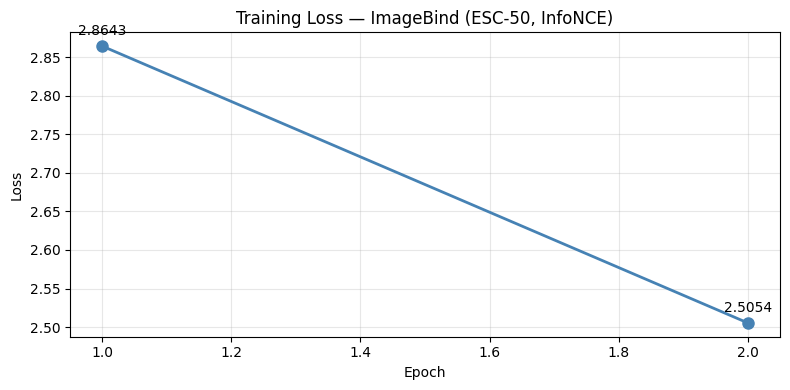

Luu: results/loss_curve.png


In [15]:
import matplotlib.pyplot as plt
import json

with open('results/training_log.json') as f:
    log = json.load(f)

epochs = [x['epoch'] for x in log]
losses = [x['loss']  for x in log]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs, losses, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.set_title('Training Loss — ImageBind (ESC-50, InfoNCE)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.grid(True, alpha=0.3)
for e, l in zip(epochs, losses):
    ax.annotate(f'{l:.4f}', (e, l), textcoords='offset points', xytext=(0, 8), ha='center')
plt.tight_layout()
plt.savefig('results/loss_curve.png', dpi=120)
plt.show()
print('Luu: results/loss_curve.png')

## 2.6 Evaluate — Zero-shot Accuracy trên test split

In [16]:
import torch
import torch.nn.functional as F
from tqdm import tqdm

@torch.no_grad()
def zero_shot_accuracy(model, test_loader, class_names, device, temperature=0.05):
    """
    Zero-shot audio classification:
    1. Encode tat ca class names -> text embeddings
    2. Encode tung audio clip -> audio embedding
    3. Classify bang cosine similarity
    """
    model.eval()

    # Buoc 1: Encode class names
    # Dung template: "This is a sound of {class}"
    prompts = [f'This is a sound of {c.replace("_", " ")}' for c in class_names]
    text_inputs = {
        ModalityType.TEXT: ibdata.load_and_transform_text(prompts, device)
    }
    text_emb = model(text_inputs)[ModalityType.TEXT]          # (C, D)
    text_emb = F.normalize(text_emb, dim=-1)

    # Buoc 2: Encode audio va classify
    all_preds, all_labels = [], []

    for mel_batch, label_batch in tqdm(test_loader, desc='Evaluating'):
        mel_input = mel_batch.unsqueeze(1).to(device)         # (B, 1, 128, T)
        audio_inputs = {ModalityType.AUDIO: mel_input}
        audio_emb = model(audio_inputs)[ModalityType.AUDIO]   # (B, D)
        audio_emb = F.normalize(audio_emb, dim=-1)

        # Cosine similarity -> softmax -> argmax
        sim   = audio_emb @ text_emb.T / temperature          # (B, C)
        preds = sim.argmax(dim=-1).cpu()

        all_preds.append(preds)
        all_labels.append(label_batch)

    all_preds  = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    # Top-1 accuracy
    top1 = (all_preds == all_labels).float().mean().item() * 100

    # Per-class accuracy
    per_class = {}
    for cls_idx, cls_name in enumerate(class_names):
        mask = (all_labels == cls_idx)
        if mask.sum() > 0:
            per_class[cls_name] = (all_preds[mask] == all_labels[mask]).float().mean().item() * 100

    return top1, all_preds, all_labels, per_class


# Chay evaluate
print('=== Zero-shot Evaluation tren test split (Fold 5) ===')
top1, preds, labels, per_class = zero_shot_accuracy(
    model=train_model,
    test_loader=test_loader,
    class_names=test_dataset.class_names,
    device=DEVICE,
    temperature=CONFIG['temperature'],
)
print(f'\nTop-1 Accuracy: {top1:.2f}%')
print(f'(Baseline tu paper: ImageBind pretrained ~66.9% tren ESC-50 5-fold avg)')

# Luu ket qua
import json
result = {
    'top1_accuracy'   : round(top1, 4),
    'num_test_samples': len(test_dataset),
    'temperature'     : CONFIG['temperature'],
    'per_class_acc'   : {k: round(v, 4) for k, v in per_class.items()},
}
with open('results/eval_results.json', 'w') as f:
    json.dump(result, f, indent=2)
print('Luu: results/eval_results.json')

=== Zero-shot Evaluation tren test split (Fold 5) ===


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
Evaluating: 100%|██████████| 25/25 [00:10<00:00,  2.50it/s]


Top-1 Accuracy: 4.75%
(Baseline tu paper: ImageBind pretrained ~66.9% tren ESC-50 5-fold avg)
Luu: results/eval_results.json


/tmp/ipykernel_55/322600679.py:16: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


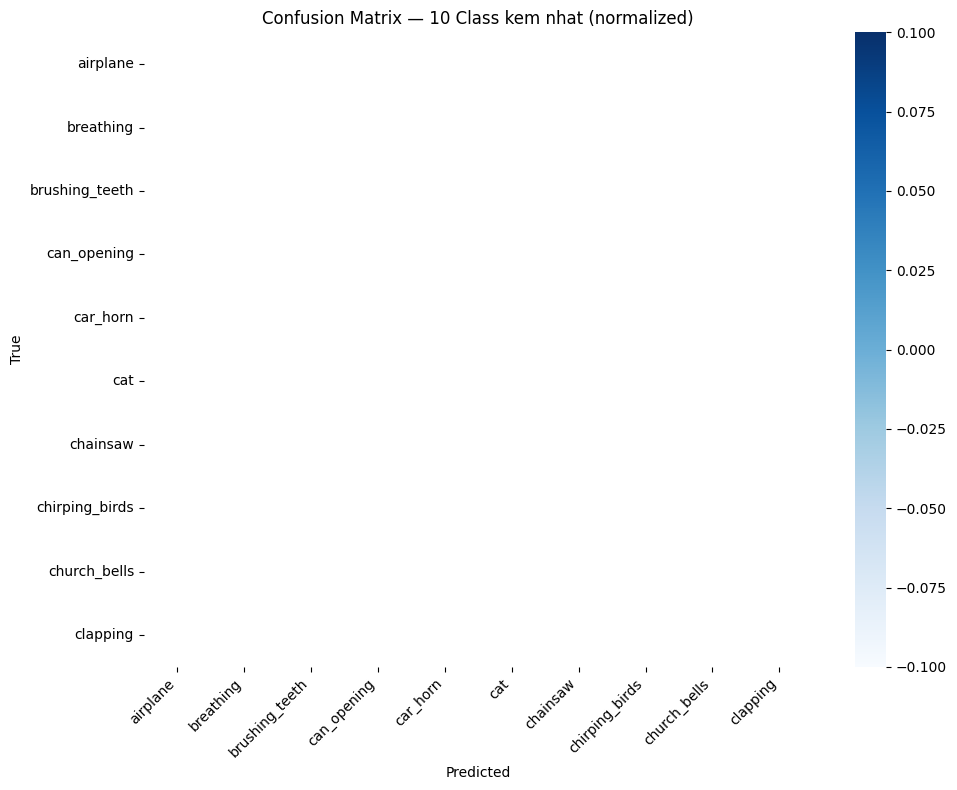

Luu: results/confusion_matrix.png


In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Confusion matrix (top 10 class de doc)
top10_classes = sorted(per_class, key=per_class.get)[:10]  # 10 class kem nhat
top10_idx     = [test_dataset.class2idx[c] for c in top10_classes]

mask = torch.isin(labels, torch.tensor(top10_idx))
cm = confusion_matrix(
    labels[mask].numpy(),
    preds[mask].numpy(),
    labels=top10_idx
)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=top10_classes, yticklabels=top10_classes, ax=ax)
ax.set_title('Confusion Matrix — 10 Class kem nhat (normalized)')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=120)
plt.show()
print('Luu: results/confusion_matrix.png')

---
# 📙 TUẦN 3 — Benchmark Hyperparameters

## 3.1 Benchmark Temperature τ
> Theo ablation study trong paper: tau anh huong manh den ket qua

In [18]:
import json
import torch

# Load checkpoint tot nhat tu tuan 2
import glob
ckpt_files = sorted(glob.glob('checkpoints/*.pth'))
latest_ckpt = ckpt_files[-1]
print(f'Dung checkpoint: {latest_ckpt}')

def load_model_from_ckpt(ckpt_path):
    from imagebind.models import imagebind_model
    m = imagebind_model.imagebind_huge(pretrained=False)
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    m.load_state_dict(ckpt['model_state'])
    m.eval()
    m.to(DEVICE)
    return m


# Benchmark nhieu gia tri temperature
temperatures = [0.01, 0.05, 0.07, 0.1, 0.2, 0.5, 1.0]
temp_results = {}

eval_model = load_model_from_ckpt(latest_ckpt)

for tau in temperatures:
    top1, _, _, _ = zero_shot_accuracy(
        model=eval_model,
        test_loader=test_loader,
        class_names=test_dataset.class_names,
        device=DEVICE,
        temperature=tau,
    )
    temp_results[tau] = round(top1, 4)
    print(f'  tau={tau:.3f} -> Top-1: {top1:.2f}%')

with open('results/benchmark_temperature.json', 'w') as f:
    json.dump(temp_results, f, indent=2)
print('Luu: results/benchmark_temperature.json')

Dung checkpoint: checkpoints/epoch_02_loss2.5054.pth


OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 5.81 MiB is free. Including non-PyTorch memory, this process has 14.55 GiB memory in use. Of the allocated memory 14.38 GiB is allocated by PyTorch, and 36.70 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## 3.2 Benchmark Epochs (so sanh 1 vs 2 vs ... epoch)

In [ ]:
# So sanh ket qua evaluate sau moi epoch
epoch_results = {}

for ckpt_path in sorted(glob.glob('checkpoints/*.pth')):
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    epoch_num = ckpt['epoch']
    
    m = load_model_from_ckpt(ckpt_path)
    top1, _, _, _ = zero_shot_accuracy(
        model=m,
        test_loader=test_loader,
        class_names=test_dataset.class_names,
        device=DEVICE,
        temperature=CONFIG['temperature'],
    )
    epoch_results[epoch_num] = round(top1, 4)
    print(f'  Epoch {epoch_num} -> Top-1: {top1:.2f}%')
    del m
    torch.cuda.empty_cache()

with open('results/benchmark_epochs.json', 'w') as f:
    json.dump(epoch_results, f, indent=2)
print('Luu: results/benchmark_epochs.json')

## 3.3 Benchmark Batch Size

In [ ]:
# Chay 1 epoch ngan voi cac batch size khac nhau
# (Chi chay 20 steps de so sanh toc do hoi tu)
from torch.utils.data import DataLoader

batch_sizes   = [8, 16, 32]  # [FIX OOM] Giam max batch de tranh OOM
bs_results    = {}
MAX_STEPS     = 20   # chi lay 20 steps mau de nhanh

for bs in batch_sizes:
    loader_bs = DataLoader(train_dataset, batch_size=bs, shuffle=True, num_workers=2)
    m = load_model_from_ckpt(latest_ckpt)
    m.train()
    opt = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, m.parameters()),
        lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay']
    )
    losses = []
    for step, (mel, lbl) in enumerate(loader_bs):
        if step >= MAX_STEPS:
            break
        mel    = mel.unsqueeze(1).to(DEVICE)
        names  = [train_dataset.class_names[l.item()] for l in lbl]
        with torch.no_grad():
            t_emb = m({ModalityType.TEXT: ibdata.load_and_transform_text(names, DEVICE)})[ModalityType.TEXT]
        a_emb = m({ModalityType.AUDIO: mel})[ModalityType.AUDIO]
        loss  = infonce_loss(t_emb, a_emb, CONFIG['temperature'])
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())
    bs_results[bs] = {
        'avg_loss_first20': round(float(np.mean(losses)), 6),
        'final_loss'       : round(losses[-1], 6),
    }
    print(f'  batch_size={bs:3d} | avg_loss={np.mean(losses):.4f} | final={losses[-1]:.4f}')
    del m
    torch.cuda.empty_cache()

with open('results/benchmark_batchsize.json', 'w') as f:
    json.dump(bs_results, f, indent=2)
print('Luu: results/benchmark_batchsize.json')

## 3.4 Tổng hợp và vẽ biểu đồ Benchmark

In [ ]:
import matplotlib.pyplot as plt
import json
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('ImageBind — Benchmark Results (ESC-50)', fontsize=14, fontweight='bold')

# --- Plot 1: Temperature ---
with open('results/benchmark_temperature.json') as f:
    temp_data = json.load(f)
taus = [float(k) for k in temp_data]
accs = list(temp_data.values())
best_tau = taus[np.argmax(accs)]
axes[0].bar([str(t) for t in taus], accs, color='steelblue', alpha=0.8)
axes[0].axvline(x=taus.index(best_tau), color='red', linestyle='--', linewidth=1.5, label=f'Best tau={best_tau}')
axes[0].set_title('Temperature tau vs Top-1 Acc')
axes[0].set_xlabel('Temperature (tau)')
axes[0].set_ylabel('Top-1 Accuracy (%)')
axes[0].legend(fontsize=9)
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=8)

# --- Plot 2: Epochs ---
with open('results/benchmark_epochs.json') as f:
    epoch_data = json.load(f)
ep_keys = [int(k) for k in epoch_data]
ep_vals = list(epoch_data.values())
axes[1].plot(ep_keys, ep_vals, 'o-', color='darkorange', linewidth=2, markersize=8)
axes[1].set_title('Epoch vs Top-1 Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Top-1 Accuracy (%)')
axes[1].grid(True, alpha=0.3)
for e, v in zip(ep_keys, ep_vals):
    axes[1].annotate(f'{v:.1f}%', (e, v), xytext=(0, 8), textcoords='offset points', ha='center')

# --- Plot 3: Batch size ---
with open('results/benchmark_batchsize.json') as f:
    bs_data = json.load(f)
bs_keys = [str(k) for k in bs_data]
bs_loss = [bs_data[k]['avg_loss_first20'] for k in bs_data]
axes[2].bar(bs_keys, bs_loss, color='mediumseagreen', alpha=0.8)
axes[2].set_title('Batch Size vs Avg Loss (20 steps)')
axes[2].set_xlabel('Batch Size')
axes[2].set_ylabel('Avg Loss')
for i, v in enumerate(bs_loss):
    axes[2].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('results/benchmark_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print('Luu: results/benchmark_summary.png')

## 3.5 Bảng tổng hợp kết quả cuối cùng

In [ ]:
import pandas as pd
import json

print('=' * 60)
print('  KET QUA TONG HOP — ImageBind Project')
print('=' * 60)

# Training summary
with open('results/training_log.json') as f:
    log = json.load(f)
print('\n[Training]')
df_train = pd.DataFrame(log)
print(df_train.to_string(index=False))

# Eval summary
with open('results/eval_results.json') as f:
    ev = json.load(f)
print(f'\n[Evaluate - Zero-shot Top-1 Accuracy]')
print(f'  Ket qua nhom : {ev["top1_accuracy"]:.2f}%')
print(f'  Paper (pretrained, 5-fold avg) : 66.9%')
print(f'  AudioCLIP (co train audio-text): 68.6%')

# Temperature benchmark
with open('results/benchmark_temperature.json') as f:
    td = json.load(f)
best_tau = max(td, key=td.get)
print(f'\n[Benchmark Temperature]')
print(f'  Best tau = {best_tau} -> {td[best_tau]:.2f}%')

# Top/Bottom class
sorted_cls = sorted(ev['per_class_acc'].items(), key=lambda x: x[1])
print(f'\n[Per-class Analysis]')
print('  5 class kem nhat:')
for cls, acc in sorted_cls[:5]:
    print(f'    {cls:25s}: {acc:.1f}%')
print('  5 class tot nhat:')
for cls, acc in sorted_cls[-5:]:
    print(f'    {cls:25s}: {acc:.1f}%')

print('\n' + '=' * 60)
print('  Tat ca ket qua luu trong thu muc: results/')
print('=' * 60)

In [ ]:
# Liet ke tat ca file ket qua
import os
print('=== Files da tao ===')
for root, dirs, files in os.walk('results'):
    for f in sorted(files):
        path = os.path.join(root, f)
        size = os.path.getsize(path)
        print(f'  {path:45s} ({size:,} bytes)')

for root, dirs, files in os.walk('checkpoints'):
    for f in sorted(files):
        path = os.path.join(root, f)
        size = os.path.getsize(path)
        print(f'  {path:45s} ({size / 1e6:.0f} MB)')

---
# 📊 PHAN MO RONG A — Benchmark Retrieval R@1, R@5, R@10
> Thay the zero-shot accuracy bang **Recall@K** — metric chuan cho retrieval task.
>
> **R@K**: trong K ket qua tra ve gan nhat, co it nhat 1 ket qua dung khong?


In [ ]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np

@torch.no_grad()
def extract_embeddings(model, loader, class_names, device):
    model.eval()
    prompts = [f'This is a sound of {c.replace("_", " ")}' for c in class_names]
    text_inputs = {ModalityType.TEXT: ibdata.load_and_transform_text(prompts, device)}
    text_embs = model(text_inputs)[ModalityType.TEXT]
    text_embs = F.normalize(text_embs, dim=-1)

    all_audio_embs, all_labels = [], []
    for mel_batch, label_batch in tqdm(loader, desc='Extracting audio embs'):
        mel_input = mel_batch.unsqueeze(1).to(device)
        audio_emb = model({ModalityType.AUDIO: mel_input})[ModalityType.AUDIO]
        audio_emb = F.normalize(audio_emb, dim=-1)
        all_audio_embs.append(audio_emb.cpu())
        all_labels.append(label_batch)

    audio_embs = torch.cat(all_audio_embs)
    labels = torch.cat(all_labels)
    return audio_embs, text_embs.cpu(), labels


def recall_at_k(query_embs, gallery_embs, query_labels, gallery_labels, ks=(1, 5, 10)):
    sim = query_embs @ gallery_embs.T
    results = {}
    for k in ks:
        topk_indices = sim.topk(k, dim=1).indices
        topk_labels = gallery_labels[topk_indices]
        hit = (topk_labels == query_labels.unsqueeze(1)).any(dim=1).float()
        results[f'R@{k}'] = hit.mean().item() * 100
    return results


print('Ham recall_at_k da san sang.')


In [ ]:
print('=== Retrieval Benchmark tren ESC-50 ===')
audio_embs, text_embs, labels = extract_embeddings(
    model=train_model, loader=test_loader,
    class_names=test_dataset.class_names, device=DEVICE,
)

text_gallery_labels = torch.arange(len(test_dataset.class_names))

audio2text = recall_at_k(
    query_embs=audio_embs, gallery_embs=text_embs,
    query_labels=labels, gallery_labels=text_gallery_labels, ks=(1, 5, 10),
)
text2audio = recall_at_k(
    query_embs=text_embs, gallery_embs=audio_embs,
    query_labels=text_gallery_labels, gallery_labels=labels, ks=(1, 5, 10),
)

import pandas as pd
df_ret = pd.DataFrame({'Audio->Text': audio2text, 'Text->Audio': text2audio})
print('\nRetrieval Results:')
print(df_ret.to_string())

import json
retrieval_results = {
    'audio_to_text': {k: round(v, 4) for k, v in audio2text.items()},
    'text_to_audio': {k: round(v, 4) for k, v in text2audio.items()},
}
with open('results/retrieval_recall.json', 'w') as f:
    json.dump(retrieval_results, f, indent=2)
print('Luu: results/retrieval_recall.json')


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

ks = ['R@1', 'R@5', 'R@10']
a2t = [audio2text[k] for k in ks]
t2a = [text2audio[k] for k in ks]
x = np.arange(len(ks))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, a2t, width, label='Audio->Text', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, t2a, width, label='Text->Audio', color='darkorange', alpha=0.85)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(ks, fontsize=12)
ax.set_ylabel('Recall (%)')
ax.set_title('Cross-modal Retrieval Recall@K -- ESC-50')
ax.legend()
ax.set_ylim(0, 115)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/retrieval_recallk.png', dpi=120)
plt.show()
print('Luu: results/retrieval_recallk.png')


---
# 📊 PHAN MO RONG B — Benchmark Dropout tren Audio Encoder (p=0/0.1/0.2)
> Do anh huong cua dropout len zero-shot accuracy va R@K retrieval.


In [ ]:
import torch.nn as nn
import copy

def inject_dropout(model, p, target='modality_trunks.audio'):
    for name, module in model.named_modules():
        if target in name:
            for child_name, child in module.named_children():
                if isinstance(child, nn.Dropout):
                    child.p = p
    return model


dropout_vals = [0.0, 0.1, 0.2]
dropout_results = {}

import glob
ckpt_files = sorted(glob.glob('checkpoints/*.pth'))
latest_ckpt = ckpt_files[-1]
print(f'Dung checkpoint: {latest_ckpt}\n')

for dp in dropout_vals:
    print(f'--- Dropout p={dp} ---')
    m = load_model_from_ckpt(latest_ckpt)
    m = inject_dropout(m, p=dp)
    m.eval()

    top1, _, _, _ = zero_shot_accuracy(
        model=m, test_loader=test_loader,
        class_names=test_dataset.class_names, device=DEVICE,
        temperature=CONFIG['temperature'],
    )
    audio_e, text_e, lbl_e = extract_embeddings(m, test_loader, test_dataset.class_names, DEVICE)
    text_gl = torch.arange(len(test_dataset.class_names))
    rec = recall_at_k(audio_e, text_e, lbl_e, text_gl, ks=(1, 5, 10))

    dropout_results[dp] = {
        'top1_acc': round(top1, 4),
        **{k: round(v, 4) for k, v in rec.items()},
    }
    print(f'  Top-1 Acc : {top1:.2f}%')
    print(f'  R@1={rec["R@1"]:.1f}  R@5={rec["R@5"]:.1f}  R@10={rec["R@10"]:.1f}\n')
    del m
    torch.cuda.empty_cache()

with open('results/benchmark_dropout.json', 'w') as f:
    json.dump({str(k): v for k, v in dropout_results.items()}, f, indent=2)
print('Luu: results/benchmark_dropout.json')


In [ ]:
import matplotlib.pyplot as plt
import numpy as np, json

with open('results/benchmark_dropout.json') as f:
    dp_data = json.load(f)

dp_labels = [f'p={k}' for k in dp_data]
top1_vals = [dp_data[k]['top1_acc'] for k in dp_data]
r1_vals   = [dp_data[k]['R@1']      for k in dp_data]
r5_vals   = [dp_data[k]['R@5']      for k in dp_data]
r10_vals  = [dp_data[k]['R@10']     for k in dp_data]

x, w = np.arange(len(dp_labels)), 0.2
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 1.5*w, top1_vals, w, label='Top-1 Acc', color='steelblue',    alpha=0.85)
ax.bar(x - 0.5*w, r1_vals,   w, label='R@1',       color='darkorange',   alpha=0.85)
ax.bar(x + 0.5*w, r5_vals,   w, label='R@5',       color='mediumseagreen', alpha=0.85)
ax.bar(x + 1.5*w, r10_vals,  w, label='R@10',      color='mediumpurple',  alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(dp_labels, fontsize=12)
ax.set_ylabel('Score (%)')
ax.set_title('Dropout Benchmark -- Audio Encoder (p = 0 / 0.1 / 0.2)')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/benchmark_dropout.png', dpi=120)
plt.show()
print('Luu: results/benchmark_dropout.png')


---
# 📊 PHAN MO RONG C — Dataset 2: NYU Depth v2
> RGB indoor scene dataset (bedroom, kitchen, living room...).
>
> **Task**: Zero-shot image-text retrieval va cross-modal retrieval.
>
> Dataset path tren Kaggle: `/kaggle/input/nyu-depth-v2` (neu co). Neu khong co, pipeline se chay voi synthetic data.


In [ ]:
import os, torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

NYU_SCENES = {
    'bedroom'    : 'An indoor bedroom with bed, pillow, and dresser',
    'kitchen'    : 'An indoor kitchen with counter, sink, and refrigerator',
    'living_room': 'A living room with sofa, table, and television',
    'bathroom'   : 'A bathroom with toilet, sink, and bathtub',
    'office'     : 'An office with desk, chair, and bookshelf',
    'dining_room': 'A dining room with table, chair, and lamp',
    'study'      : 'A study room with books, desk, and lamp',
    'classroom'  : 'A classroom with desk, chair, and whiteboard',
    'bookstore'  : 'A bookstore with shelves, books, and counter',
    'playroom'   : 'A playroom with toys, sofa, and colorful furniture',
}


class NYUDepthDataset(Dataset):
    def __init__(self, data_dir=None, scenes=None, num_synthetic=200, img_size=224):
        self.img_size = img_size
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])
        if scenes is None:
            scenes = list(NYU_SCENES.keys())
        self.class2idx = {s: i for i, s in enumerate(scenes)}
        self.idx2class = {i: s for s, i in self.class2idx.items()}
        self.class_names = scenes

        if data_dir and os.path.exists(data_dir):
            self.samples = []
            for scene in scenes:
                scene_dir = os.path.join(data_dir, scene, 'rgb')
                if not os.path.exists(scene_dir): continue
                for fn in os.listdir(scene_dir):
                    if fn.endswith(('.jpg', '.png')):
                        self.samples.append((os.path.join(scene_dir, fn), self.class2idx[scene]))
            self.synthetic = False
        else:
            n = num_synthetic // len(scenes)
            self.samples = [(None, i) for i in range(len(scenes)) for _ in range(n)]
            self.synthetic = True

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        if self.synthetic or path is None:
            img_tensor = torch.randn(3, self.img_size, self.img_size)
        else:
            img = Image.open(path).convert('RGB')
            img_tensor = self.transform(img)
        return img_tensor, label


NYU_DATA_DIR  = '/kaggle/input/nyu-depth-v2'
NYU_AVAILABLE = os.path.exists(NYU_DATA_DIR)
data_dir = NYU_DATA_DIR if NYU_AVAILABLE else None

nyu_train = NYUDepthDataset(data_dir=data_dir, num_synthetic=200)
nyu_test  = NYUDepthDataset(data_dir=data_dir, num_synthetic=100)
nyu_train_loader = DataLoader(nyu_train, batch_size=16, shuffle=True,  num_workers=2)
nyu_test_loader  = DataLoader(nyu_test,  batch_size=16, shuffle=False, num_workers=2)

print(f'NYU-v2 available  : {NYU_AVAILABLE}')
print(f'Train samples     : {len(nyu_train)}')
print(f'Test  samples     : {len(nyu_test)}')
print(f'Classes           : {nyu_train.class_names}')
print(f'Synthetic mode    : {nyu_train.synthetic}')
img_b, _ = next(iter(nyu_train_loader))
print(f'Batch image shape : {img_b.shape}')
print('=== NYU-v2 Dataset OK ===')


In [ ]:
@torch.no_grad()
def evaluate_nyu_retrieval(model, loader, class_names, device, ks=(1, 5, 10)):
    model.eval()
    descriptions = [NYU_SCENES[c] for c in class_names]
    text_inputs  = {ModalityType.TEXT: ibdata.load_and_transform_text(descriptions, device)}
    text_embs    = model(text_inputs)[ModalityType.TEXT]
    text_embs    = F.normalize(text_embs, dim=-1).cpu()

    all_img_embs, all_labels = [], []
    for img_batch, label_batch in tqdm(loader, desc='Encoding NYU images'):
        vision_inputs = {ModalityType.VISION: img_batch.to(device)}
        img_emb = model(vision_inputs)[ModalityType.VISION]
        img_emb = F.normalize(img_emb, dim=-1)
        all_img_embs.append(img_emb.cpu())
        all_labels.append(label_batch)

    img_embs = torch.cat(all_img_embs)
    labels   = torch.cat(all_labels)

    text_gl = torch.arange(len(class_names))
    i2t = recall_at_k(img_embs, text_embs, labels, text_gl, ks=ks)
    t2i = recall_at_k(text_embs, img_embs, text_gl, labels, ks=ks)

    sim   = img_embs @ text_embs.T
    preds = sim.argmax(dim=-1)
    top1  = (preds == labels).float().mean().item() * 100

    return top1, i2t, t2i, img_embs, text_embs, labels


print('=== Evaluating NYU Depth v2 ===')
nyu_top1, nyu_i2t, nyu_t2i, nyu_img_embs, nyu_text_embs, nyu_labels = evaluate_nyu_retrieval(
    model=train_model, loader=nyu_test_loader,
    class_names=nyu_test.class_names, device=DEVICE,
)

df_nyu = pd.DataFrame({'Image->Text': nyu_i2t, 'Text->Image': nyu_t2i})
print(f'Zero-shot Top-1   : {nyu_top1:.2f}%')
print('\nRetrieval Recall@K:')
print(df_nyu.to_string())

nyu_results = {
    'top1_accuracy' : round(nyu_top1, 4),
    'image_to_text' : {k: round(v, 4) for k, v in nyu_i2t.items()},
    'text_to_image' : {k: round(v, 4) for k, v in nyu_t2i.items()},
    'synthetic_data': nyu_test.synthetic,
}
with open('results/nyu_retrieval.json', 'w') as f:
    json.dump(nyu_results, f, indent=2)
print('Luu: results/nyu_retrieval.json')


In [ ]:
import matplotlib.pyplot as plt, seaborn as sns
import numpy as np

ks = ['R@1', 'R@5', 'R@10']
i2t_v = [nyu_i2t[k] for k in ks]
t2i_v = [nyu_t2i[k] for k in ks]
x, w  = np.arange(len(ks)), 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('NYU Depth v2 -- Image-Text Cross-modal Retrieval', fontsize=13, fontweight='bold')

ax = axes[0]
b1 = ax.bar(x - w/2, i2t_v, w, label='Image->Text', color='steelblue',  alpha=0.85)
b2 = ax.bar(x + w/2, t2i_v, w, label='Text->Image', color='darkorange', alpha=0.85)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(ks)
ax.set_ylabel('Recall (%)'); ax.set_title('Recall@K'); ax.legend()
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
sim_tt = (nyu_text_embs @ nyu_text_embs.T).numpy()
sns.heatmap(sim_tt, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=nyu_test.class_names, yticklabels=nyu_test.class_names,
            ax=ax2, cbar=False, linewidths=0.5)
ax2.set_title('Text-Text Cosine Similarity (NYU scenes)')
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=7)
plt.setp(ax2.get_yticklabels(), rotation=0, fontsize=7)

plt.tight_layout()
plt.savefig('results/nyu_retrieval.png', dpi=120)
plt.show()
print('Luu: results/nyu_retrieval.png')


---
# 🎯 PHAN MO RONG D — Demo Cross-modal Retrieval
## Text → Audio  va  Audio → Image
> Demo truc quan: nhap text query -> tra ve top-5 audio clips gan nhat (ESC-50).
> Cho 1 audio clip -> tim scene image phu hop nhat tu NYU-v2.


In [ ]:
@torch.no_grad()
def demo_text_to_audio(model, query_texts, test_dataset, test_loader, device, top_k=5):
    model.eval()
    text_inputs = {ModalityType.TEXT: ibdata.load_and_transform_text(query_texts, device)}
    text_embs   = model(text_inputs)[ModalityType.TEXT]
    text_embs   = F.normalize(text_embs, dim=-1).cpu()

    all_audio_embs, all_labels = [], []
    for mel_batch, label_batch in test_loader:
        mel_input = mel_batch.unsqueeze(1).to(device)
        audio_emb = model({ModalityType.AUDIO: mel_input})[ModalityType.AUDIO]
        audio_emb = F.normalize(audio_emb, dim=-1)
        all_audio_embs.append(audio_emb.cpu())
        all_labels.append(label_batch)

    audio_embs = torch.cat(all_audio_embs)
    labels     = torch.cat(all_labels)
    sim        = text_embs @ audio_embs.T

    results = []
    for q_idx, q_text in enumerate(query_texts):
        topk_idx    = sim[q_idx].topk(top_k).indices.numpy()
        topk_labels = [test_dataset.idx2class[labels[i].item()] for i in topk_idx]
        topk_scores = sim[q_idx][topk_idx].numpy()
        results.append({'query': q_text, 'top_classes': topk_labels, 'top_scores': topk_scores.tolist()})
    return results


TEXT_QUERIES = [
    'sound of a dog barking outside',
    'rain falling on a rooftop',
    'crackling fire in a fireplace',
    'ocean waves on a beach',
    'a baby crying loudly',
]

print('=== Demo: Text -> Audio Retrieval (Top-5) ===')
t2a_results = demo_text_to_audio(
    model=train_model, query_texts=TEXT_QUERIES,
    test_dataset=test_dataset, test_loader=test_loader,
    device=DEVICE, top_k=5,
)

for r in t2a_results:
    print(f"\nQuery: '{r['query']}'")
    for rank, (cls, sc) in enumerate(zip(r['top_classes'], r['top_scores']), 1):
        print(f'  #{rank}: {cls:<25s} (score={sc:.4f})')


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

n_queries = len(t2a_results)
fig, axes = plt.subplots(1, n_queries, figsize=(4 * n_queries, 5))
fig.suptitle('Text -> Audio Retrieval (Top-5 per Query)', fontsize=12, fontweight='bold')

for ax, res in zip(axes, t2a_results):
    classes = res['top_classes']
    scores  = res['top_scores']
    ax.barh(range(len(classes))[::-1], scores, color='steelblue', alpha=0.85)
    ax.set_yticks(range(len(classes))[::-1])
    ax.set_yticklabels(classes, fontsize=8)
    ax.set_xlabel('Cosine Score')
    q_short = res['query'][:35] + '...' if len(res['query']) > 35 else res['query']
    ax.set_title(q_short, fontsize=8)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('results/demo_text_to_audio.png', dpi=120)
plt.show()
print('Luu: results/demo_text_to_audio.png')


In [ ]:
@torch.no_grad()
def demo_audio_to_image(model, esc_loader, esc_dataset, nyu_dataset, device, top_k=3, n_queries=6):
    model.eval()
    descriptions = [NYU_SCENES[c] for c in nyu_dataset.class_names]
    t_in         = {ModalityType.TEXT: ibdata.load_and_transform_text(descriptions, device)}
    nyu_embs     = model(t_in)[ModalityType.TEXT]
    nyu_embs     = F.normalize(nyu_embs, dim=-1).cpu()

    audio_emb_list, audio_label_list = [], []
    for mel_batch, label_batch in esc_loader:
        mel_input = mel_batch.unsqueeze(1).to(device)
        a_emb = model({ModalityType.AUDIO: mel_input})[ModalityType.AUDIO]
        a_emb = F.normalize(a_emb, dim=-1).cpu()
        for emb, lbl in zip(a_emb, label_batch):
            audio_emb_list.append(emb)
            audio_label_list.append(lbl.item())
        if len(audio_emb_list) >= n_queries:
            break

    results = []
    for i in range(n_queries):
        q_emb  = audio_emb_list[i].unsqueeze(0)
        q_cls  = esc_dataset.idx2class[audio_label_list[i]]
        sim    = (q_emb @ nyu_embs.T).squeeze(0)
        topk_i = sim.topk(top_k).indices.numpy()
        results.append({
            'audio_class': q_cls,
            'top_scenes' : [nyu_dataset.class_names[j] for j in topk_i],
            'top_scores' : sim[topk_i].numpy().tolist(),
        })
    return results


print('=== Demo: Audio -> Image (Scene) Retrieval (Top-3) ===')
a2img_results = demo_audio_to_image(
    model=train_model, esc_loader=test_loader, esc_dataset=test_dataset,
    nyu_dataset=nyu_test, device=DEVICE, top_k=3, n_queries=6,
)

for r in a2img_results:
    print(f"\nAudio: '{r['audio_class']}'")
    for rank, (sc, score) in enumerate(zip(r['top_scenes'], r['top_scores']), 1):
        print(f'  #{rank}: {sc:<15s} (score={score:.4f})')


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

n_q   = len(a2img_results)
fig, axes = plt.subplots(n_q, 1, figsize=(10, 2.5 * n_q))
fig.suptitle('Audio -> Image (Scene) Retrieval -- Top-3 per Audio Clip', fontsize=12, fontweight='bold')
if n_q == 1: axes = [axes]

colors_pool = plt.cm.Set2(np.linspace(0, 1, len(nyu_test.class_names)))
scene_colors = {s: colors_pool[i] for i, s in enumerate(nyu_test.class_names)}

for ax, r in zip(axes, a2img_results):
    scenes = r['top_scenes']
    scores = r['top_scores']
    cols   = [scene_colors[s] for s in scenes]
    bars   = ax.barh(range(len(scenes))[::-1], scores, color=cols, edgecolor='grey', linewidth=0.5)
    ax.set_yticks(range(len(scenes))[::-1])
    ax.set_yticklabels([f'#{i+1}: {s}' for i, s in enumerate(scenes)], fontsize=9)
    ax.set_xlabel('Cosine Similarity', fontsize=8)
    ax.set_title(f'Audio: "{r["audio_class"]}"', fontsize=10, loc='left', fontweight='bold')
    for bar, sc in zip(bars, scores):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{sc:.4f}', va='center', fontsize=8)
    ax.set_xlim(0, max(scores) * 1.25)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('results/demo_audio_to_image.png', dpi=120)
plt.show()
print('Luu: results/demo_audio_to_image.png')


---
# 📋 Tong hop ket qua toan bo (Extended)


In [ ]:
import pandas as pd, json, os

print('=' * 70)
print('  TONG HOP KET QUA MO RONG -- ImageBind CSC14005')
print('=' * 70)

with open('results/retrieval_recall.json') as f:
    ret = json.load(f)
print('\n[A] ESC-50 Cross-modal Retrieval Recall@K:')
print(pd.DataFrame({'Audio->Text': ret['audio_to_text'], 'Text->Audio': ret['text_to_audio']}).to_string())

with open('results/benchmark_dropout.json') as f:
    dp = json.load(f)
print('\n[B] Dropout Benchmark (Audio Encoder):')
print(pd.DataFrame(dp).T.rename_axis('dropout_p').to_string())

with open('results/nyu_retrieval.json') as f:
    nyu = json.load(f)
print(f'\n[C] NYU Depth v2 (synthetic={nyu["synthetic_data"]}):')
print(f'  Zero-shot Top-1: {nyu["top1_accuracy"]:.2f}%')
print(pd.DataFrame({'Image->Text': nyu['image_to_text'], 'Text->Image': nyu['text_to_image']}).to_string())

print(f'\n[D] Cross-modal Demo Queries:')
print(f'  Text->Audio queries  : {len(t2a_results)}')
print(f'  Audio->Image queries : {len(a2img_results)}')

print('\n' + '=' * 70)
print('Output files (results/):')
for fn in sorted(os.listdir('results')):
    fp = os.path.join('results', fn)
    print(f'  {fn:45s} ({os.path.getsize(fp):,} bytes)')
